## 1.1 Definição do problema

O objetivo principal deste projeto é estudar a **eficiência académica** dos estudantes, procurando perceber se o sucesso académico depende apenas do número de horas de estudo ou se resulta de uma combinação mais ampla de fatores, como **capacidade de foco, qualidade do descanso, hábitos digitais e bem-estar geral**.

Esta questão é relevante porque, em contextos educativos atuais, os estudantes estão expostos a múltiplas fontes de distração e a padrões de vida que podem influenciar significativamente o seu desempenho. Assim, mais do que estudar durante mais tempo, importa compreender **que fatores estão associados a estudar melhor**.

Com base nesta perspetiva, foram definidos dois cenários preditivos complementares:

- **Cenário de Regressão:** estimar o valor de `focus_index`, representando o nível de concentração do estudante durante o estudo.
- **Cenário de Classificação:** prever se um estudante deverá obter um desempenho elevado no exame, através da variável binária `high_exam_score`, construída a partir de `exam_score`.

Desta forma, o projeto procura responder simultaneamente a duas questões:

1. **Que fatores ajudam a explicar o nível de foco de um estudante?**
2. **Será possível prever se um estudante terá um desempenho elevado no exame com base nos seus hábitos e características?**

A combinação destes dois cenários permite analisar a eficiência académica de forma mais completa, relacionando não apenas o resultado final, mas também uma dimensão comportamental intermédia essencial: o foco.

## 1.2 Stakeholders

Os resultados deste estudo podem ser úteis para diferentes intervenientes no contexto académico.

- **Estudantes:** podem obter informação sobre se o aumento do tempo de estudo, por si só, é suficiente para melhorar o desempenho, ou se fatores como foco, descanso e bem-estar têm um papel mais determinante.
- **Docentes, mentores e tutores:** podem utilizar estes resultados para sugerir estratégias de estudo mais eficazes e personalizadas, ajustadas aos perfis e necessidades dos estudantes.
- **Serviços de apoio ao estudante:** podem beneficiar destas conclusões para desenhar intervenções preventivas orientadas para hábitos saudáveis, equilíbrio digital e melhoria das condições de aprendizagem.
- **Coordenação académica ou instituições de ensino:** podem usar este tipo de análise para apoiar decisões relacionadas com acompanhamento pedagógico, prevenção de insucesso e promoção do bem-estar académico.

Assim, o valor do projeto não está apenas na construção de modelos preditivos, mas também na possibilidade de produzir conhecimento útil para apoiar decisões educativas e promover estratégias de aprendizagem mais sustentáveis.

## 1.3. Imports

Nesta secção são importadas todas as bibliotecas necessárias para o desenvolvimento do projeto. Incluem-se ferramentas para manipulação de dados, análise estatística, pré-processamento, criação de pipelines e preparação das fases de treino e avaliação dos modelos.

In [237]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import tree
from sklearn.metrics import ConfusionMatrixDisplay

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, RobustScaler


from sklearn.model_selection import train_test_split, cross_validate, GridSearchCV


from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.svm import SVR, SVC
from sklearn.cluster import KMeans

from sklearn.metrics import RocCurveDisplay
import io
import matplotlib.image as mpimg
import pydot
from sklearn.metrics import roc_curve, auc

from sklearn.metrics import (
    mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, silhouette_score
)

## 2. Load e limpeza primária

Nesta fase é feito o carregamento do dataset, a validação da variável-alvo escolhida e a remoção de colunas sem utilidade preditiva, como identificadores. Em seguida, é realizada uma limpeza primária com o objetivo de inspecionar os dados e documentar o seu estado antes e depois do tratamento dos valores em falta.

Esta etapa tem um propósito sobretudo exploratório e descritivo. Para efeitos de modelação, o pré-processamento final será posteriormente integrado num pipeline reprodutível, evitando transformações inconsistentes entre treino e teste.

In [238]:
# =========================
# CONFIGURAÇÃO
# =========================
link = r"Dados_Projeto\student_records_missing.csv"
allowed_cols = ["focus_index", "burnout_level", "productivity_score", "exam_score"]

# Tema escolhido:
# Regressão -> focus_index
# Classificação -> exam_score binário
target_reg = "focus_index"
target_clf_base = "exam_score"


# =========================
# FUNÇÕES AUXILIARES
# =========================
def summarize_numeric(df):
    #nomes das colunas numéricas
    
    num_cols = df.select_dtypes(include=np.number).columns.tolist()
    real_cols = []
    for col in num_cols:
        if not col.startswith("cat__"):
            real_cols.append(col)
    
    num_cols = real_cols 
    if not num_cols:
        return pd.DataFrame()

    summary = df[num_cols].agg(["count", "mean", "std", "min", "median", "max"]).T
    #valores em falta por coluna
    summary["missing"] = df[num_cols].isna().sum()
    summary = summary[["count", "missing", "mean", "std", "min", "median", "max"]]

    return summary.round(3)


def summarize_categorical(df):
    #nomes das colunas categóricas
    cat_cols = []
    cat_cols = df.select_dtypes(exclude=np.number).columns.tolist()
    if not cat_cols:
        for col in df.columns:
            if col.startswith("cat__"):
                cat_cols.append(col)
    rows = []
    for col in cat_cols:
        s = df[col]
        mode = s.mode(dropna=True)
        unique = s.dropna().unique().tolist()
        uniqueValues = []
        for val in unique:
            uniqueValues.append(s[s == val].count())
        
        rows.append({
            "variable": col,
            "count": s.notna().sum(),
            "missing": s.isna().sum(),
            "unique": s.nunique(dropna=True),
            "mode": mode.iloc[0] if not mode.empty else None,
            "possible_values": unique,
            "unique_values": uniqueValues
        })

    if rows:
        return pd.DataFrame(rows).set_index("variable")
    return pd.DataFrame()


def print_full_summary(title, df):
    print("\n" + "=" * 90)
    print(title)
    print("=" * 90)

    print(f"\nShape: {df.shape}")

    print("\nTipos de dados:")
    print(df.dtypes)

    print("\nValores em falta por coluna:")
    print(df.isna().sum())

    print("\n--- Resumo Numérico ---")
    num_summary = summarize_numeric(df)
    if not num_summary.empty:
        print(num_summary)
    else:
        print("Sem colunas numéricas.")

    print("\n--- Resumo Categórico ---")
    cat_summary = summarize_categorical(df)
    if not cat_summary.empty:
        print(cat_summary)
    else:
        print("Sem colunas categóricas.")


def load_project_data(fname, target_reg, target_clf_base):
    df = pd.read_csv(fname)

    for target in [target_reg, target_clf_base]:
        if target not in allowed_cols:
            raise ValueError(f"Target inválido: {target}. Targets permitidos: {allowed_cols}")

        if target not in df.columns:
            raise ValueError(f"Target '{target}' não encontrado no dataset.")

    # Criar target binário da classificação
    #1 - acima da mediana, 0 - abaixo da mediana (equilibra melhor as classes)
    threshold = df[target_clf_base].quantile(0.9)
    df["high_exam_score"] = (df[target_clf_base] >= threshold).astype(int)

    # Remover ID e targets que não entram como feature
    cols_to_drop = [
        "student_id",
        "focus_index",
        "exam_score",
        "high_exam_score",
        "burnout_level",
        "productivity_score"
    ]

    X_raw = df.drop(columns=cols_to_drop, errors="ignore").copy()
    y_reg = df[target_reg].copy()
    y_clf = df["high_exam_score"].copy()

    return df, X_raw, y_reg, y_clf, threshold


# =========================
# EXECUÇÃO
# =========================
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

df, X_raw, y_reg, y_clf, exam_threshold = load_project_data(link, target_reg, target_clf_base)

print("Target da regressão:", target_reg)
print("Target da classificação: high_exam_score")
print("Threshold usado para high_exam_score:", round(exam_threshold, 3))

print("\nDistribuição da variável de classificação:")
print(y_clf.value_counts())



Target da regressão: focus_index
Target da classificação: high_exam_score
Threshold usado para high_exam_score: 35.093

Distribuição da variável de classificação:
high_exam_score
0    4500
1     500
Name: count, dtype: int64


## 3. Justificação técnica do pré-processamento

O pré-processamento foi definido com o objetivo de preparar o dataset para modelação de forma **reprodutível, consistente e metodologicamente correta**, respeitando a natureza mista das variáveis disponíveis.

### 3.1 Tratamento de valores em falta

A análise inicial do dataset mostrou a existência de valores em falta em várias variáveis, tanto numéricas como categóricas. Entre as variáveis com missing values destacam-se `mental_health_score`, `caffeine_intake_mg`, `screen_time_hours`, `social_media_hours`, `gender` e `academic_level`. Como muitos algoritmos de aprendizagem automática não suportam diretamente valores em falta, tornou-se necessário aplicar uma estratégia de imputação.

Nas variáveis numéricas foi escolhida a **mediana** como valor de imputação. Esta opção é tecnicamente adequada porque várias variáveis apresentam distribuições potencialmente assimétricas e amplitudes relativamente largas, como por exemplo `caffeine_intake_mg`, `exercise_minutes` e `screen_time_hours`. Nestes casos, a mediana é preferível à média por ser menos sensível a valores extremos e por preservar melhor a tendência central dos dados observados.

Nas variáveis categóricas foi utilizada imputação pela **categoria mais frequente**. Esta escolha permite substituir valores em falta por uma categoria plausível e coerente com a distribuição observada, sem introduzir categorias artificiais ou perder observações do dataset.

Embora tenha sido realizada uma análise descritiva inicial fora do pipeline, a imputação final foi integrada no pipeline com `SimpleImputer`, garantindo que os parâmetros são aprendidos apenas a partir dos dados de treino e aplicados de forma consistente aos dados de teste e às folds de validação cruzada. Isto evita **data leakage** e assegura correção metodológica.

### 3.2 Codificação de variáveis categóricas

O dataset inclui variáveis categóricas como gender, academic_level e internet_quality. A inspeção dos seus valores possíveis mostra que estas variáveis representam categorias nominais, ou seja, categorias sem uma ordem quantitativa natural.

Por exemplo, categorias como Male, Female e Other em gender, ou Good, Average e Poor em internet_quality, não devem ser interpretadas como níveis numéricos com distância fixa entre si. Neste contexto, a utilização de um OrdinalEncoder introduziria relações artificiais entre categorias, levando o modelo a interpretar incorretamente que uma categoria poderia ser “maior” ou “menor” do que outra.

Por essa razão, foi utilizada codificação com OneHotEncoder. Esta abordagem transforma cada variável categórica nominal em variáveis dummy, preservando a natureza não ordinal das categorias e evitando a introdução de ordenações inexistentes.

No entanto, o encoder foi configurado com drop="first", o que significa que, em cada variável categórica, uma das categorias é removida e passa a funcionar como categoria de referência. Esta opção foi adotada para evitar multicolinearidade perfeita entre variáveis dummy, situação particularmente relevante em modelos lineares, onde a presença simultânea de todas as categorias pode gerar redundância exata e instabilidade numérica na estimação dos coeficientes.

Desta forma, os coeficientes associados às categorias codificadas devem ser interpretados relativamente à categoria omitida, e não de forma absoluta.

Além disso, como cada variável categórica apresenta apenas um número reduzido de categorias distintas, o aumento de dimensionalidade causado pela one-hot encoding mantém-se controlado e aceitável. O encoder foi ainda configurado com handle_unknown="ignore" para permitir que categorias não vistas durante o treino possam ser tratadas sem erro em dados futuros ou em folds de validação cruzada.

Se quiseres, eu também posso corrigir a parte do teu comentário no código sobre o RobustScaler, porque aí também tens uma pequena inconsistência técnica.

### 3.3 Escalonamento de variáveis numéricas

As variáveis numéricas do dataset apresentam escalas bastante diferentes. Por exemplo, `age` varia numa amplitude curta, enquanto `exercise_minutes` e `caffeine_intake_mg` assumem valores muito mais elevados. Sem escalonamento, estas diferenças de magnitude poderiam influenciar desproporcionalmente algoritmos sensíveis à escala, como regressão logística, regressão linear e métodos baseados em distância.

Para lidar com este problema foi utilizado **`RobustScaler`**. Esta escolha foi motivada pela distribuição estatística observada nas variáveis numéricas: várias apresentam sinais de assimetria e possibilidade de valores extremos, nomeadamente `study_hours`, `self_study_hours`, `screen_time_hours`, `exercise_minutes` e `caffeine_intake_mg`. Nestes casos, métodos de escalonamento baseados na média e no desvio-padrão, como `StandardScaler`, podem ser excessivamente influenciados por outliers.

O `RobustScaler` centra os dados na mediana e escala-os com base no intervalo interquartil (IQR), tornando-se mais adequado para distribuições não perfeitamente simétricas e mais robusto à presença de observações extremas. Esta opção é também consistente com a escolha da mediana como estratégia de imputação para variáveis numéricas.

Tal como nas restantes transformações, o escalonamento foi integrado no pipeline para garantir que todos os parâmetros são aprendidos exclusivamente nos dados de treino, evitando fuga de informação e assegurando reprodutibilidade.

### 3.4 Síntese do pipeline

Em conjunto, o pipeline de pré-processamento foi construído para responder às características observadas no dataset:

- existência de **valores em falta** em variáveis numéricas e categóricas;
- presença de **variáveis categóricas nominais**, sem ordem natural;
- diferenças de escala entre variáveis numéricas;
- indícios de **assimetria e sensibilidade a outliers** em várias features.

Desta forma, a combinação de imputação, one-hot encoding e robust scaling permite transformar o dataset numa representação numérica consistente, adequada para avaliação justa dos modelos e metodologicamente correta em treino, teste e validação cruzada.

In [239]:
# =========================
# PIPELINE DE PRÉ-PROCESSAMENTO
# =========================

numeric_features = X_raw.select_dtypes(include=np.number).columns.tolist()
categorical_features = X_raw.select_dtypes(exclude=np.number).columns.tolist()

print("Colunas numéricas:")
print(numeric_features)

print("\nColunas categóricas:")
print(categorical_features)

## ANTES DO PIPELINE
print_full_summary("VALORES ANTES DO PIPELINE DE PRÉ-PROCESSAMENTO", X_raw)


# Pipeline numérico
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    # RobustScaler centra os dados na mediana (=0) e escala usando o IQR, ficando mais robusto a outliers
    # o que é consistente com a imputação pela mediana e com a natureza
    # potencialmente assimétrica das variáveis do dataset
    
    ("scaler", RobustScaler())
])

# Pipeline categórico
categorical_transformer = Pipeline(steps=[
    #preenche valores em falta com a categoria mais frequente
    ("imputer", SimpleImputer(strategy="most_frequent")),
    #transforma categorias em variáveis dummy (0/1) e ignora categorias desconhecidas no teste
    ("onehot", OneHotEncoder(handle_unknown="ignore", drop="first"))
])

# Preprocessador final
preprocessor = ColumnTransformer(
    transformers=[
        #(nome, pipeline, aplicar a estas colunas)
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ],
    remainder="drop"
)

# Teste do pipeline

#fit(aprende medianas-> missing, medias e desvios-> scaling, categorias-> onehot) + transform(aplica aos dados)
X_processed = preprocessor.fit_transform(X_raw)

print("\nShape antes do pipeline:", X_raw.shape)
print("Shape depois do pipeline:", X_processed.shape) #aumenta num columns; onehot expande colunas categóricas em várias colunas dummy

feature_names_out = preprocessor.get_feature_names_out()

print(f"\n{len(feature_names_out)} Features transformadas:")
print(feature_names_out)



##APOS PIPELINE
print_full_summary("VALORES APÓS PIPELINE DE PRÉ-PROCESSAMENTO", pd.DataFrame(X_processed, columns=feature_names_out))


#resumo final

print("\n" + "=" * 90)
print("RESUMO FINAL DA LIMPEZA PRIMÁRIA")
print("=" * 90)
print("Número total de features:", X_raw.shape[1])
print("Missing values antes do pipeline:", X_raw.isna().sum().sum())
missing_after = (
    np.isnan(X_processed.toarray()).sum()
    if hasattr(X_processed, "toarray")
    else pd.isna(X_processed).sum().sum()
)

print("Missing values depois do pipeline:", int(missing_after))


Colunas numéricas:
['age', 'study_hours', 'self_study_hours', 'online_classes_hours', 'social_media_hours', 'gaming_hours', 'sleep_hours', 'screen_time_hours', 'exercise_minutes', 'caffeine_intake_mg', 'part_time_job', 'upcoming_deadline', 'mental_health_score']

Colunas categóricas:
['gender', 'academic_level', 'internet_quality']

VALORES ANTES DO PIPELINE DE PRÉ-PROCESSAMENTO

Shape: (5000, 16)

Tipos de dados:
age                       int64
gender                   object
academic_level           object
study_hours             float64
self_study_hours        float64
online_classes_hours    float64
social_media_hours      float64
gaming_hours            float64
sleep_hours             float64
screen_time_hours       float64
exercise_minutes          int64
caffeine_intake_mg      float64
part_time_job             int64
upcoming_deadline         int64
internet_quality         object
mental_health_score     float64
dtype: object

Valores em falta por coluna:
age                       

## 4. Modelos baseline

Nesta fase foram selecionados modelos baseline simples e interpretáveis, com o objetivo de estabelecer uma referência inicial de desempenho. Estes modelos permitem avaliar o comportamento dos dados antes da utilização de abordagens mais complexas.

Para a tarefa de regressão foi utilizada `LinearRegression` como modelo principal e `DecisionTreeRegressor` como modelo de comparação.

Para a tarefa de classificação foi utilizada `LogisticRegression` como modelo principal e `DecisionTreeClassifier` como modelo de comparação.

In [240]:
# =========================
# 4. MODELOS BASELINE
# =========================

RANDOM_STATE = 42

# Split treino/teste
X_train, X_test, y_train_reg, y_test_reg, y_train_clf, y_test_clf = train_test_split(
    X_raw, y_reg, y_clf,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_clf
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train_reg:", y_train_reg.shape)
print("y_test_reg:", y_test_reg.shape)
print("y_train_clf:", y_train_clf.shape)
print("y_test_clf:", y_test_clf.shape)


# =========================
# PIPELINES DOS MODELOS
# =========================

# Regressão
reg_models = {
    "LinearRegression": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]),
    "DecisionTreeRegressor": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", DecisionTreeRegressor(random_state=RANDOM_STATE, max_depth=5))
    ])
}

# Classificação
clf_models = {
    "LogisticRegression": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))
    ]),
    "DecisionTreeClassifier": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", DecisionTreeClassifier(random_state=RANDOM_STATE, max_depth=5))
    ])
}

X_train: (4000, 16)
X_test: (1000, 16)
y_train_reg: (4000,)
y_test_reg: (1000,)
y_train_clf: (4000,)
y_test_clf: (1000,)



## 5. Métricas de avaliação

Foram definidas métricas adequadas a cada tipo de problema, de forma a avaliar corretamente o desempenho dos modelos.

Na regressão foi utilizada como métrica principal o `RMSE` e como métrica secundária o `R²`. Na classificação foi utilizado o `F1-score` como métrica principal e a `Accuracy` como métrica secundária.

Estas métricas permitem analisar tanto o erro dos modelos como a sua capacidade de generalização.


In [241]:
# =========================
# 5. MÉTRICAS E FUNÇÕES AUXILIARES
# =========================

def evaluate_regression(model, X_train, X_test, y_train, y_test, model_name):
    model.fit(X_train, y_train)

    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
    rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))

    r2_train = r2_score(y_train, y_pred_train)
    r2_test = r2_score(y_test, y_pred_test)

    print("\n" + "="*80)
    print(f"REGRESSÃO - {model_name}")
    print("="*80)
    print(f"RMSE treino: {rmse_train:.4f}")
    print(f"RMSE teste : {rmse_test:.4f}")
    print(f"R² treino  : {r2_train:.4f}")
    print(f"R² teste   : {r2_test:.4f}")

    return {
        "model": model_name,
        "rmse_train": rmse_train,
        "rmse_test": rmse_test,
        "r2_train": r2_train,
        "r2_test": r2_test
    }


def evaluate_classification(model, X_train, X_test, y_train, y_test, model_name):
    model.fit(X_train, y_train)

    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    acc_train = accuracy_score(y_train, y_pred_train)
    acc_test = accuracy_score(y_test, y_pred_test)

    f1_train = f1_score(y_train, y_pred_train)
    f1_test = f1_score(y_test, y_pred_test)

    print("\n" + "="*80)
    print(f"CLASSIFICAÇÃO - {model_name}")
    print("="*80)
    print(f"Accuracy treino: {acc_train:.4f}")
    print(f"Accuracy teste : {acc_test:.4f}")
    print(f"F1 treino      : {f1_train:.4f}")
    print(f"F1 teste       : {f1_test:.4f}")

    print("\nMatriz de confusão:")
    print(confusion_matrix(y_test, y_pred_test))

    print("\nClassification report:")
    print(classification_report(y_test, y_pred_test))

    return {
        "model": model_name,
        "accuracy_train": acc_train,
        "accuracy_test": acc_test,
        "f1_train": f1_train,
        "f1_test": f1_test
    }


## 6. Treino e avaliação dos modelos

Os modelos foram treinados utilizando pipelines que integram o pré-processamento definido anteriormente, garantindo consistência entre treino e teste.

Os dados foram divididos em conjuntos de treino e teste, e o desempenho dos modelos foi avaliado com base nas métricas definidas. Adicionalmente, foi utilizada validação cruzada para obter resultados mais robustos.

In [242]:
# =========================
# 6. TREINO E AVALIAÇÃO DOS MODELOS
# =========================

reg_results = []
for name, model in reg_models.items():
    result = evaluate_regression(model, X_train, X_test, y_train_reg, y_test_reg, name)
    reg_results.append(result)

clf_results = []
for name, model in clf_models.items():
    result = evaluate_classification(model, X_train, X_test, y_train_clf, y_test_clf, name)
    clf_results.append(result)

reg_results_df = pd.DataFrame(reg_results).sort_values(by="rmse_test")
clf_results_df = pd.DataFrame(clf_results).sort_values(by="f1_test", ascending=False)

print("\nResumo dos modelos de regressão:")
print(reg_results_df)

print("\nResumo dos modelos de classificação:")
print(clf_results_df)



REGRESSÃO - LinearRegression
RMSE treino: 5.4733
RMSE teste : 5.8888
R² treino  : 0.6989
R² teste   : 0.6471

REGRESSÃO - DecisionTreeRegressor
RMSE treino: 6.6414
RMSE teste : 7.3302
R² treino  : 0.5566
R² teste   : 0.4532

CLASSIFICAÇÃO - LogisticRegression
Accuracy treino: 0.9277
Accuracy teste : 0.9310
F1 treino      : 0.5601
F1 teste       : 0.5917

Matriz de confusão:
[[881  19]
 [ 50  50]]

Classification report:
              precision    recall  f1-score   support

           0       0.95      0.98      0.96       900
           1       0.72      0.50      0.59       100

    accuracy                           0.93      1000
   macro avg       0.84      0.74      0.78      1000
weighted avg       0.92      0.93      0.93      1000


CLASSIFICAÇÃO - DecisionTreeClassifier
Accuracy treino: 0.9243
Accuracy teste : 0.9120
F1 treino      : 0.4294
F1 teste       : 0.3333

Matriz de confusão:
[[890  10]
 [ 78  22]]

Classification report:
              precision    recall  f1-score 

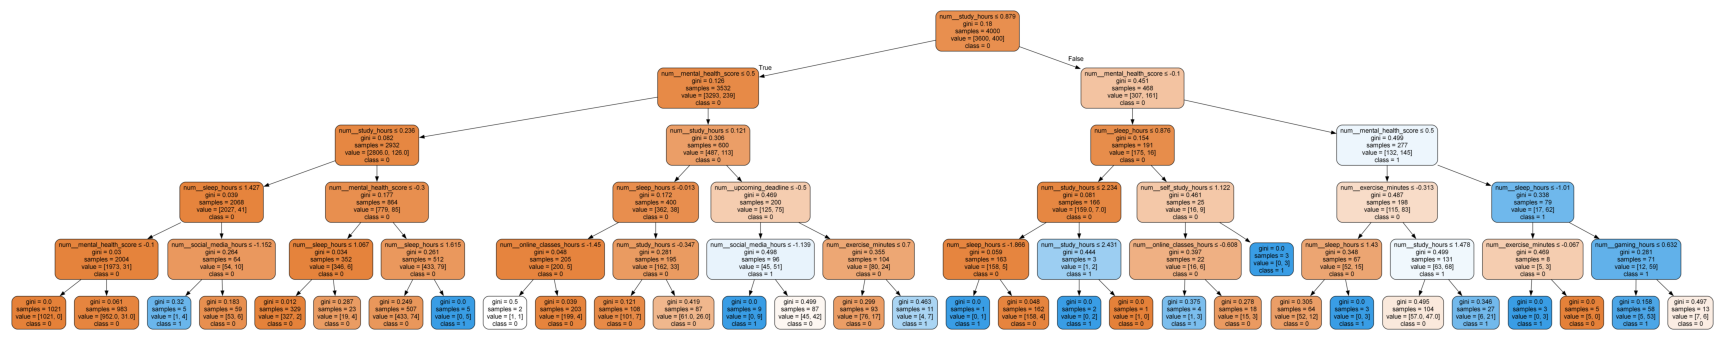

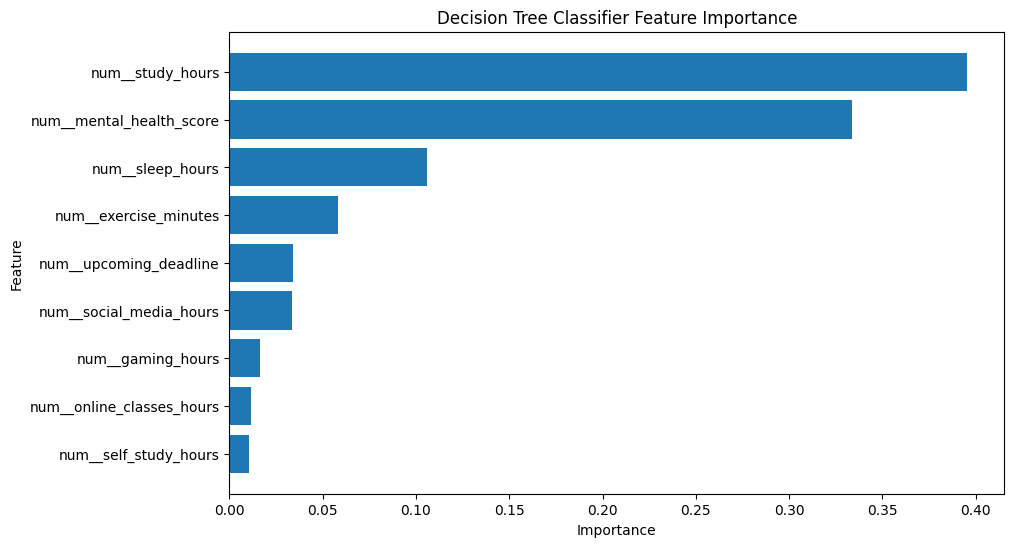


Top features - Decision Tree Classifier:
                      feature  importance
1            num__study_hours    0.395651
12   num__mental_health_score    0.333983
6            num__sleep_hours    0.105938
8       num__exercise_minutes    0.058442
11     num__upcoming_deadline    0.033937
4     num__social_media_hours    0.033354
5           num__gaming_hours    0.016355
3   num__online_classes_hours    0.011825
2       num__self_study_hours    0.010514


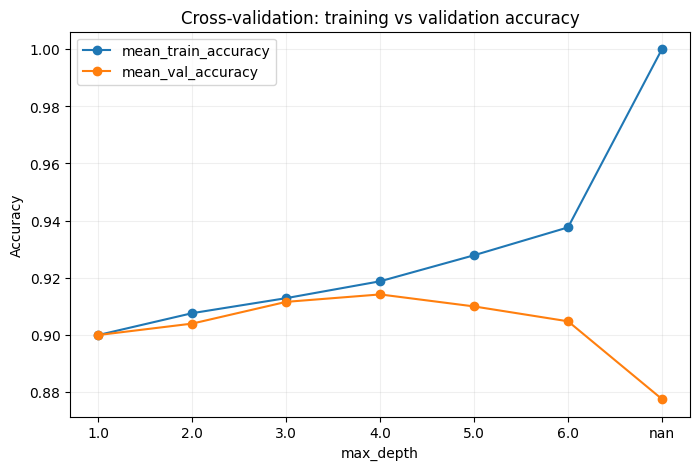

   max_depth  mean_train_accuracy  mean_val_accuracy
0        1.0              0.90000             0.9000
1        2.0              0.90765             0.9040
2        3.0              0.91290             0.9116
3        4.0              0.91880             0.9142
4        5.0              0.92790             0.9100
5        6.0              0.93765             0.9048
6        NaN              1.00000             0.8776


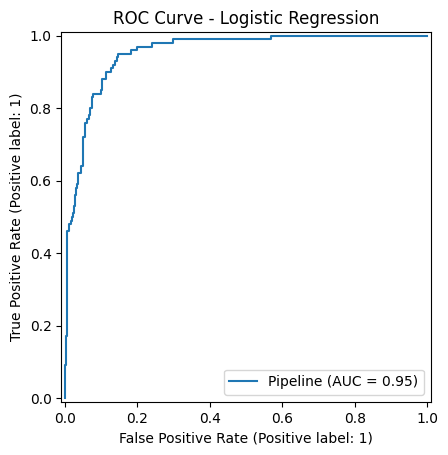

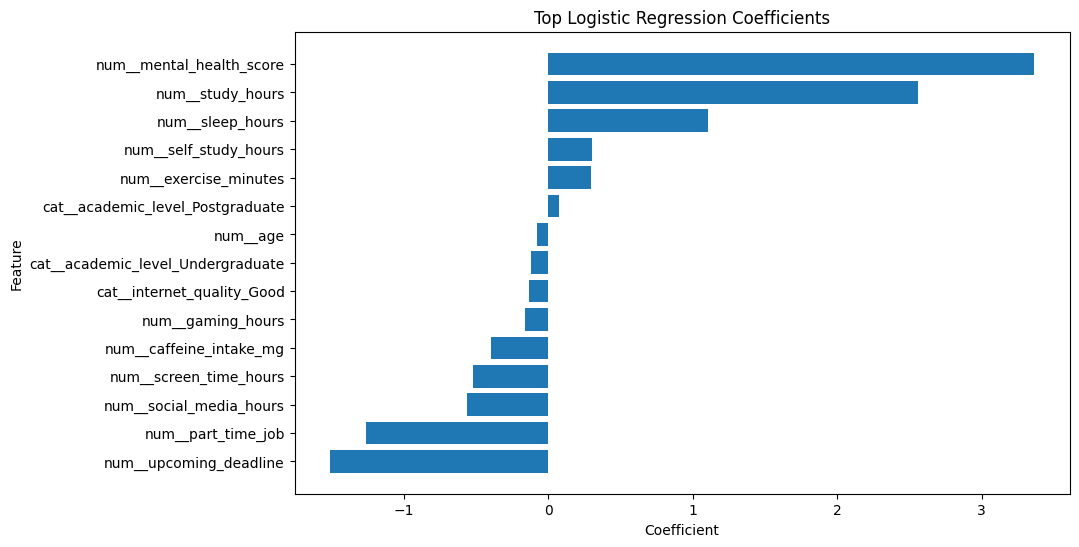


Top coefficients - Logistic Regression:
                              feature  coefficient  abs_coefficient
12           num__mental_health_score     3.365012         3.365012
1                    num__study_hours     2.560866         2.560866
11             num__upcoming_deadline    -1.514746         1.514746
10                 num__part_time_job    -1.263824         1.263824
6                    num__sleep_hours     1.106496         1.106496
4             num__social_media_hours    -0.561836         0.561836
7              num__screen_time_hours    -0.523768         0.523768
9             num__caffeine_intake_mg    -0.399511         0.399511
2               num__self_study_hours     0.300085         0.300085
8               num__exercise_minutes     0.291963         0.291963
5                   num__gaming_hours    -0.162612         0.162612
17         cat__internet_quality_Good    -0.134116         0.134116
16  cat__academic_level_Undergraduate    -0.117553         0.117553
0      

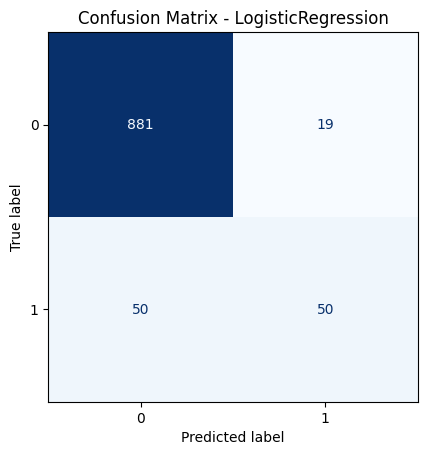

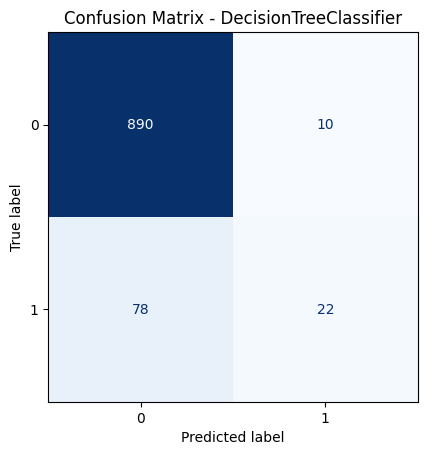

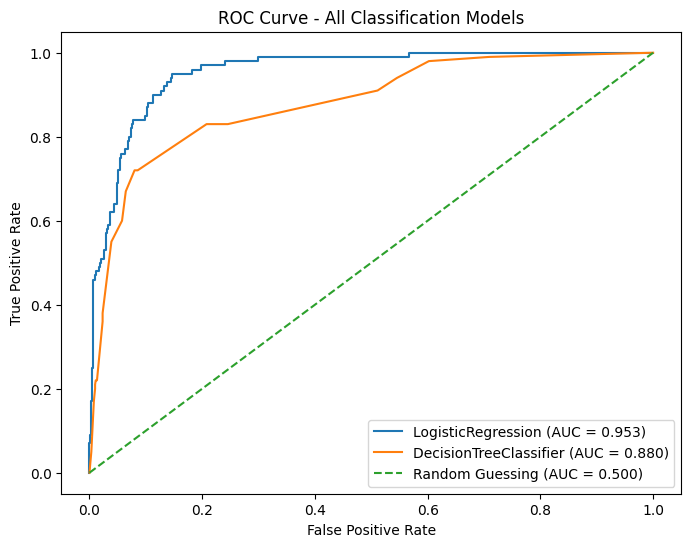

In [243]:

# =========================
# 6.1.1 VISUALIZAÇÃO DA DECISION TREE CLASSIFIER
# =========================
def display_tree(the_tree, feature_names, class_names, fname=None, figsize=(10,10)):
    dot_data = tree.export_graphviz(
        the_tree,
        feature_names=feature_names,
        class_names=class_names,
        filled=True,
        rounded=True,
        special_characters=True
    )

    graph = pydot.graph_from_dot_data(dot_data)[0]
    png = graph.create_png()

    graph.set_dpi(300)  # increase resolution
    png = graph.create_png()
    img = mpimg.imread(io.BytesIO(png))

    plt.figure(figsize=figsize)
    plt.axis("off")
    plt.imshow(img)

    if fname:
        graph.write_png(f"{fname}.png")

dt_clf_pipeline = clf_models["DecisionTreeClassifier"]
dt_clf_pipeline.fit(X_train, y_train_clf)

dt_clf = dt_clf_pipeline.named_steps["model"]
feature_names_clf = dt_clf_pipeline.named_steps["preprocessor"].get_feature_names_out()
class_names_clf = [str(c) for c in dt_clf.classes_]

display_tree(
    dt_clf,
    feature_names=feature_names_clf,
    class_names=class_names_clf,
    fname="decision_tree_classifier",
    figsize=(22, 10)
)

# =========================
# 6.1.2 IMPORTÂNCIA DAS FEATURES NA DECISION TREE CLASSIFIER
# =========================

importance_clf_df = pd.DataFrame({
    "feature": feature_names_clf,
    "importance": dt_clf.feature_importances_
}).sort_values("importance", ascending=False)

importance_clf_df = importance_clf_df[importance_clf_df["importance"] > 0]

plt.figure(figsize=(10, 6))
top_imp_clf = importance_clf_df.head(15).sort_values("importance")
plt.barh(top_imp_clf["feature"], top_imp_clf["importance"])
plt.title("Decision Tree Classifier Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

print("\nTop features - Decision Tree Classifier:")
print(importance_clf_df.head(15))

# =========================
# 6.1.3 CROSS-VALIDATION - DECISION TREE CLASSIFIER COM DIFERENTES MAX_DEPTH
# =========================

max_depth_values = [1, 2, 3, 4, 5, 6, None]
cv_depth_rows = []

for depth in max_depth_values:
    dt_depth_pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", DecisionTreeClassifier(random_state=RANDOM_STATE, max_depth=depth))
    ])

    scores = cross_validate(
        dt_depth_pipeline,
        X_raw,
        y_clf,
        cv=5,
        scoring={"accuracy": "accuracy"},
        return_train_score=True,
        n_jobs=-1
    )

    cv_depth_rows.append({
        "max_depth": depth,
        "mean_train_accuracy": scores["train_accuracy"].mean(),
        "mean_val_accuracy": scores["test_accuracy"].mean()
    })

cv_depth_df = pd.DataFrame(cv_depth_rows)
x_labels = cv_depth_df["max_depth"].astype(str)

plt.figure(figsize=(8, 5))
plt.plot(x_labels, cv_depth_df["mean_train_accuracy"], marker="o", label="mean_train_accuracy")
plt.plot(x_labels, cv_depth_df["mean_val_accuracy"], marker="o", label="mean_val_accuracy")
plt.title("Cross-validation: training vs validation accuracy")
plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

print(cv_depth_df)


# =========================
# 6.1.4 SCATTERPLOT - LOGISTIC REGRESSION
# =========================


log_reg_pipeline = clf_models["LogisticRegression"]
log_reg_pipeline.fit(X_train, y_train_clf)

RocCurveDisplay.from_estimator(log_reg_pipeline, X_test, y_test_clf)
plt.title("ROC Curve - Logistic Regression")
plt.show()


# =========================
# 6.1.5 COEFFICIENT IMPORTANCE - LOGISTIC REGRESSION
# =========================

log_reg_pipeline = clf_models["LogisticRegression"]
log_reg_pipeline.fit(X_train, y_train_clf)

feature_names_log = log_reg_pipeline.named_steps["preprocessor"].get_feature_names_out()
coefs_log = log_reg_pipeline.named_steps["model"].coef_[0]

coef_log_df = pd.DataFrame({
    "feature": feature_names_log,
    "coefficient": coefs_log,
    "abs_coefficient": np.abs(coefs_log)
}).sort_values("abs_coefficient", ascending=False)

top_log = coef_log_df.head(15).sort_values("coefficient")

plt.figure(figsize=(10, 6))
plt.barh(top_log["feature"], top_log["coefficient"])
plt.title("Top Logistic Regression Coefficients")
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.show()

print("\nTop coefficients - Logistic Regression:")
print(coef_log_df.head(15))


# =========================
# 6.1.6 CONFUSION MATRICES - CLASSIFICATION MODELS
# =========================


for name, model in clf_models.items():
    model.fit(X_train, y_train_clf)
    y_pred = model.predict(X_test)

    ConfusionMatrixDisplay.from_predictions(
        y_test_clf,
        y_pred,
        cmap="Blues",
        colorbar=False
    )

    plt.title(f"Confusion Matrix - {name}")
    plt.show()
    
    

# =========================
# 6.1.6 ROC CURVE - ALL CLASSIFICATION MODELS
# =========================

plt.figure(figsize=(8, 6))

for name, model in clf_models.items():
    model.fit(X_train, y_train_clf)

    # probability of class 1
    y_prob = model.predict_proba(X_test)[:, 1]

    fpr, tpr, _ = roc_curve(y_test_clf, y_prob)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.3f})")

# random baseline
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Guessing (AUC = 0.500)")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - All Classification Models")
plt.legend(loc="lower right")
plt.show()

## Aqui estão apenas os de regressao

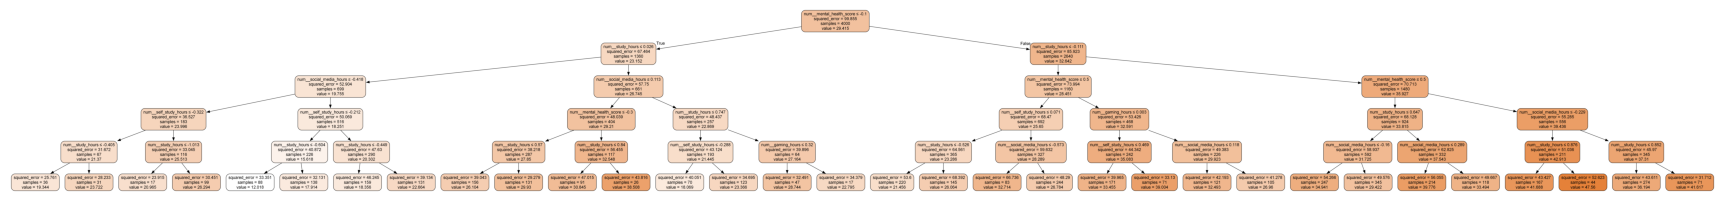

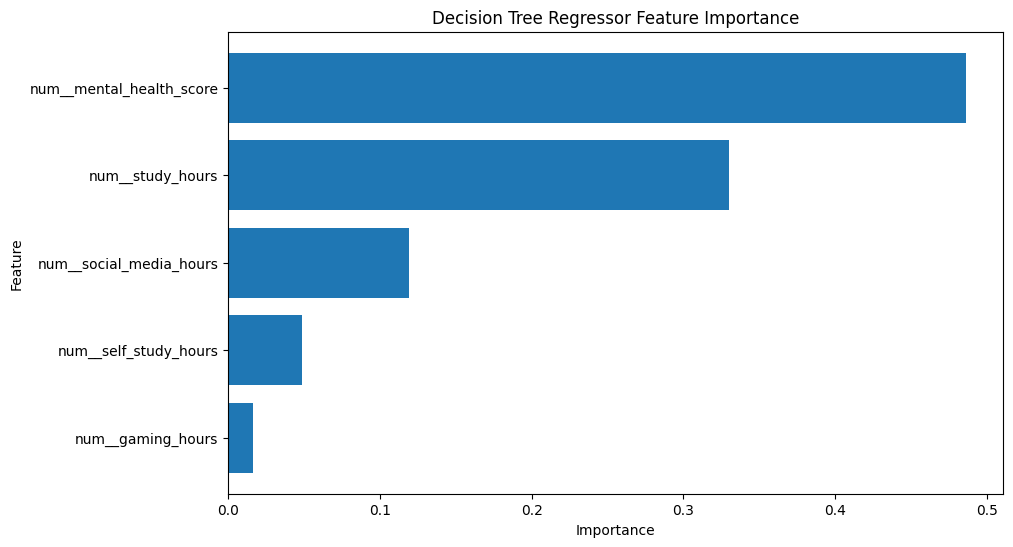


Top features - Decision Tree Regressor:
                     feature  importance
12  num__mental_health_score    0.486663
1           num__study_hours    0.329944
4    num__social_media_hours    0.118935
2      num__self_study_hours    0.048307
5          num__gaming_hours    0.016151


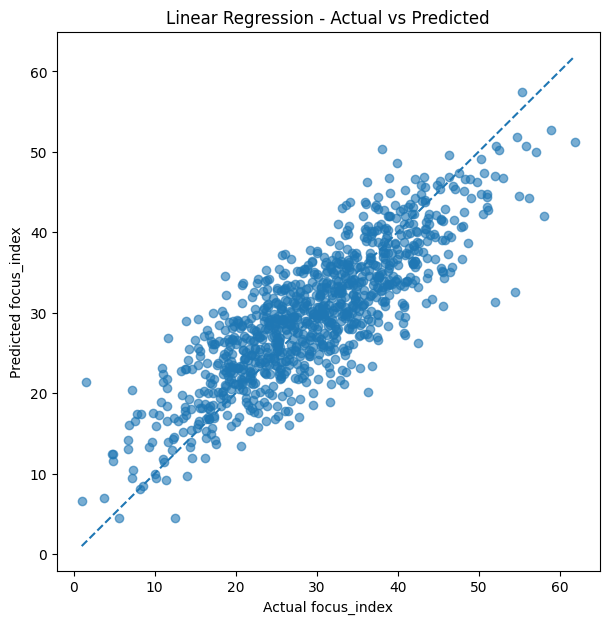

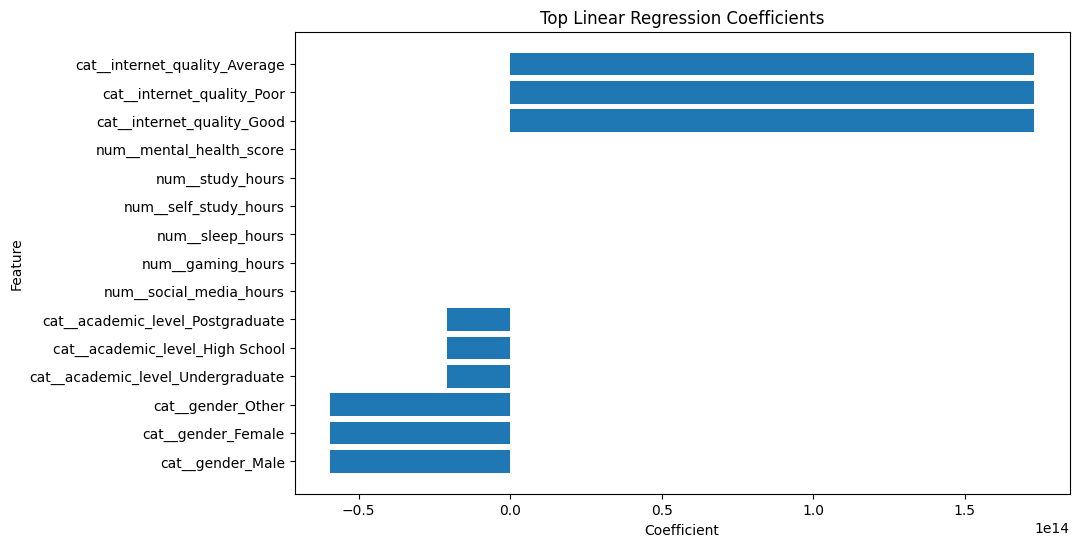


Top coefficients - Linear Regression:
                              feature   coefficient  abs_coefficient
19      cat__internet_quality_Average  1.729414e+14     1.729414e+14
21         cat__internet_quality_Poor  1.729414e+14     1.729414e+14
20         cat__internet_quality_Good  1.729414e+14     1.729414e+14
14                   cat__gender_Male -5.955419e+13     5.955419e+13
13                 cat__gender_Female -5.955419e+13     5.955419e+13
15                  cat__gender_Other -5.955419e+13     5.955419e+13
18  cat__academic_level_Undergraduate -2.091869e+13     2.091869e+13
16    cat__academic_level_High School -2.091869e+13     2.091869e+13
17   cat__academic_level_Postgraduate -2.091869e+13     2.091869e+13
12           num__mental_health_score  9.852438e+00     9.852438e+00
1                    num__study_hours  6.267330e+00     6.267330e+00
4             num__social_media_hours -3.995379e+00     3.995379e+00
2               num__self_study_hours  3.184271e+00     3.184271

In [228]:
# =========================
# 6.2.1 VISUALIZAÇÃO DA DECISION TREE REGRESSOR
# =========================
dt_reg_pipeline = reg_models["DecisionTreeRegressor"]
dt_reg_pipeline.fit(X_train, y_train_reg)

dt_reg = dt_reg_pipeline.named_steps["model"]
feature_names_reg_tree = dt_reg_pipeline.named_steps["preprocessor"].get_feature_names_out()

display_tree(
    dt_reg,
    feature_names=feature_names_reg_tree,
    class_names=None,  # regressão
    fname="decision_tree_regressor",
    figsize=(22, 10)
)

# =========================
# 6.2.2 IMPORTÂNCIA DAS FEATURES NA DECISION TREE REGRESSOR
# =========================

importance_reg_tree_df = pd.DataFrame({
    "feature": feature_names_reg_tree,
    "importance": dt_reg.feature_importances_
}).sort_values("importance", ascending=False)

importance_reg_tree_df = importance_reg_tree_df[importance_reg_tree_df["importance"] > 0]

plt.figure(figsize=(10, 6))
top_imp_reg_tree = importance_reg_tree_df.head(15).sort_values("importance")
plt.barh(top_imp_reg_tree["feature"], top_imp_reg_tree["importance"])
plt.title("Decision Tree Regressor Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

print("\nTop features - Decision Tree Regressor:")
print(importance_reg_tree_df.head(15))

# =========================
# 6.2.3 SCATTERPLOT - DECISION TREE REGRESSOR
# =========================


lin_reg_pipeline = reg_models["LinearRegression"]
lin_reg_pipeline.fit(X_train, y_train_reg)

y_pred_reg = lin_reg_pipeline.predict(X_test)

plt.figure(figsize=(7, 7))
plt.scatter(y_test_reg, y_pred_reg, alpha=0.6)

# linha ideal: previsão = valor real
min_val = min(y_test_reg.min(), y_pred_reg.min())
max_val = max(y_test_reg.max(), y_pred_reg.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

plt.xlabel("Actual focus_index")
plt.ylabel("Predicted focus_index")
plt.title("Linear Regression - Actual vs Predicted")
plt.show()

# =========================
# 6.2.4 COEFICIENTES DA LINEAR REGRESSION
# =========================

lin_reg_pipeline = reg_models["LinearRegression"]
lin_reg_pipeline.fit(X_train, y_train_reg)

feature_names_reg = lin_reg_pipeline.named_steps["preprocessor"].get_feature_names_out()
coefs_reg = lin_reg_pipeline.named_steps["model"].coef_

coef_reg_df = pd.DataFrame({
    "feature": feature_names_reg,
    "coefficient": coefs_reg,
    "abs_coefficient": np.abs(coefs_reg)
}).sort_values("abs_coefficient", ascending=False)

top_reg = coef_reg_df.head(15).sort_values("coefficient")

plt.figure(figsize=(10, 6))
plt.barh(top_reg["feature"], top_reg["coefficient"])
plt.title("Top Linear Regression Coefficients")
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.show()

print("\nTop coefficients - Linear Regression:")
print(coef_reg_df.head(15))

In [217]:
# =========================
# 7. VALIDAÇÃO CRUZADA
# =========================

reg_scoring = {
    "rmse": "neg_root_mean_squared_error",
    "r2": "r2"
}

clf_scoring = {
    "f1": "f1",
    "accuracy": "accuracy"
}

cv_reg_results = []
for name, model in reg_models.items():
    scores = cross_validate(
        model,
        X_raw,
        y_reg,
        cv=5,
        scoring=reg_scoring,
        return_train_score=True,
        n_jobs=-1
    )

    cv_reg_results.append({
        "model": name,
        "cv_rmse_train_mean": -scores["train_rmse"].mean(),
        "cv_rmse_test_mean": -scores["test_rmse"].mean(),
        "cv_r2_train_mean": scores["train_r2"].mean(),
        "cv_r2_test_mean": scores["test_r2"].mean()
    })

cv_clf_results = []
for name, model in clf_models.items():
    scores = cross_validate(
        model,
        X_raw,
        y_clf,
        cv=5,
        scoring=clf_scoring,
        return_train_score=True,
        n_jobs=-1
    )

    cv_clf_results.append({
        "model": name,
        "cv_f1_train_mean": scores["train_f1"].mean(),
        "cv_f1_test_mean": scores["test_f1"].mean(),
        "cv_accuracy_train_mean": scores["train_accuracy"].mean(),
        "cv_accuracy_test_mean": scores["test_accuracy"].mean()
    })

cv_reg_df = pd.DataFrame(cv_reg_results).sort_values(by="cv_rmse_test_mean").reset_index(drop=True)
cv_clf_df = pd.DataFrame(cv_clf_results).sort_values(by="cv_f1_test_mean", ascending=False).reset_index(drop=True)

print("\nValidação cruzada - Regressão")
print(cv_reg_df)

print("\nValidação cruzada - Classificação")
print(cv_clf_df)







Validação cruzada - Regressão
                   model  cv_rmse_train_mean  cv_rmse_test_mean  cv_r2_train_mean  cv_r2_test_mean
0       LinearRegression            5.558915           5.570153          0.688584         0.686789
1  DecisionTreeRegressor            6.699618           7.222822          0.547674         0.473690

Validação cruzada - Classificação
                    model  cv_f1_train_mean  cv_f1_test_mean  cv_accuracy_train_mean  cv_accuracy_test_mean
0      LogisticRegression          0.821429         0.814176                 0.82135                 0.8146
1  DecisionTreeClassifier          0.794725         0.770045                 0.78660                 0.7590


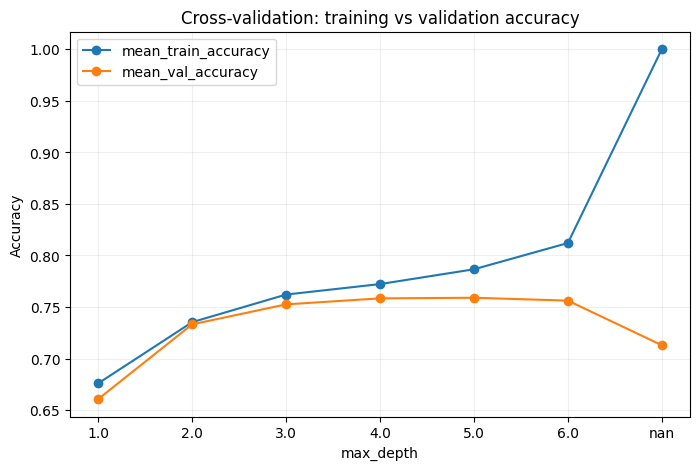

   max_depth  mean_train_accuracy  mean_val_accuracy
0        1.0              0.67605             0.6608
1        2.0              0.73535             0.7332
2        3.0              0.76210             0.7526
3        4.0              0.77225             0.7584
4        5.0              0.78660             0.7590
5        6.0              0.81205             0.7562
6        NaN              1.00000             0.7130


In [218]:
# =========================
# 8. GRÁFICO FINAL: TRAIN VS VALIDATION ACCURACY
# =========================

max_depth_values = [1, 2, 3, 4, 5, 6, None]
cv_depth_rows = []

for depth in max_depth_values:
    dt_depth_pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", DecisionTreeClassifier(random_state=RANDOM_STATE, max_depth=depth))
    ])

    scores = cross_validate(
        dt_depth_pipeline,
        X_raw,
        y_clf,
        cv=5,
        scoring={"accuracy": "accuracy"},
        return_train_score=True,
        n_jobs=-1
    )

    cv_depth_rows.append({
        "max_depth": depth,
        "mean_train_accuracy": scores["train_accuracy"].mean(),
        "mean_val_accuracy": scores["test_accuracy"].mean()
    })

cv_depth_df = pd.DataFrame(cv_depth_rows)
x_labels = cv_depth_df["max_depth"].astype(str)

plt.figure(figsize=(8, 5))
plt.plot(x_labels, cv_depth_df["mean_train_accuracy"], marker="o", label="mean_train_accuracy")
plt.plot(x_labels, cv_depth_df["mean_val_accuracy"], marker="o", label="mean_val_accuracy")
plt.title("Cross-validation: training vs validation accuracy")
plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

print(cv_depth_df)